# A/A Test: Customer Lookalike Methodology Validation (No Segmentation)

## Purpose

Validates the **Customer Lookalike synthetic control methodology** by running it against historical periods where **no campaign was active**. The expected result is **zero uplift** and **zero incremental orders**. Any non-zero result quantifies the methodology's inherent measurement bias.

## Methodology

1. Select customers from a market (e.g., DE) during a confirmed non-campaign period
2. Randomly split them into treatment (1) and potential lookalike (0) — no actual treatment is applied
3. Run the **exact same matching logic** as the production V3 script (exact match + KNN fallback)
4. Calculate uplift metrics — all should be ~0%
5. Repeat across multiple time windows and random seeds to assess stability

## Pass/Fail Criteria

| Verdict | Condition |
|---------|----------|
| **PASS** | |mean uplift| ≤ 2% AND 95% CI contains zero |
| **WARNING** | |mean uplift| > 2% OR 95% CI excludes zero |
| **HARD FAIL** | |mean uplift| > 5% in any period |

---
## 1. Imports & Authentication

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from google.colab import auth
from google.cloud import bigquery

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_style('whitegrid')

auth.authenticate_user()
print('Authenticated')

PROJECT_ID = 'just-data-gci-dev'
client = bigquery.Client(project=PROJECT_ID)
print(f'Connected to project: {PROJECT_ID}')

Authenticated
Connected to project: just-data-gci-dev


---
## 2. Configuration

In [2]:
# ============================================================
# A/A TEST CONFIGURATION
# ============================================================

# Markets to test
COUNTRIES = ['DE']

# Number of random treatment/control splits per time window
N_SEEDS = 10

# Proportion assigned to treatment group
TREATMENT_SHARE = 0.5

# Bias thresholds for pass/fail
BIAS_THRESHOLD_HARD = 0.05  # |uplift| > 5% = HARD FAIL
BIAS_THRESHOLD_WARN = 0.02  # |uplift| > 2% = WARNING

# Campaign name prefix for A/A test runs
AA_CAMPAIGN_PREFIX = 'AA_CUSTOMER_TEST'

# Non-overlapping 30-day dummy windows where NO real campaign was active
# IMPORTANT: validate these against the campaign calendar before running
TIME_WINDOWS = [
    {'start': '2024-06-01', 'end': '2024-06-30',
     'post_start': '2024-07-01', 'post_end': '2024-07-31'},
    {'start': '2024-08-01', 'end': '2024-08-31',
     'post_start': '2024-09-01', 'post_end': '2024-09-30'},
    {'start': '2024-10-01', 'end': '2024-10-31',
     'post_start': '2024-11-01', 'post_end': '2024-11-30'},
    {'start': '2025-02-01', 'end': '2025-02-28',
     'post_start': '2025-03-01', 'post_end': '2025-03-31'},
]

# V3 matching conditions (identical to production script)
LOOK_ALIKE_CONDITIONS = [
    'country', 'optin', 'campaign_start_date',
    'L14D_orders', 'L30D_orders', 'L90D_orders', 'L365D_orders'
]

# Dedicated A/A tables — avoids touching production tables
AA_AUDIENCE_TABLE = 'just-data-warehouse.customer_intelligence.customer_lookalike_aa_audience'

print('Configuration loaded.')
print(f'Markets: {COUNTRIES}')
print(f'Time windows: {len(TIME_WINDOWS)}')
print(f'Seeds per window: {N_SEEDS}')
print(f'Total runs: {len(COUNTRIES) * len(TIME_WINDOWS) * N_SEEDS}')

Configuration loaded.
Markets: ['DE']
Time windows: 4
Seeds per window: 10
Total runs: 40


---
## 3. Validate No Campaign Overlap

In [3]:
def validate_no_campaign_overlap(client, countries, time_windows):
    """Check that no real campaigns overlap with the chosen A/A test windows."""
    checks = []
    for country in countries:
        for w in time_windows:
            query = f"""
            SELECT COUNT(*) as cnt
            FROM `just-data-warehouse.customer_intelligence.customer_lookalike_evaluation_audience`
            WHERE country = '{country}'
              AND (
                (campaign_start_date BETWEEN '{w['start']}' AND '{w['post_end']}')
                OR (campaign_end_date BETWEEN '{w['start']}' AND '{w['post_end']}')
              )
            """
            result = client.query(query).to_dataframe()
            cnt = result['cnt'].iloc[0]
            checks.append({
                'country': country,
                'window': f"{w['start']} to {w['post_end']}",
                'overlapping_rows': cnt,
            })

    df_checks = pd.DataFrame(checks)
    if df_checks['overlapping_rows'].sum() > 0:
        print('WARNING: Campaign overlap detected in these windows:')
        print(df_checks[df_checks['overlapping_rows'] > 0])
        print('\nAdjust TIME_WINDOWS to avoid these periods.')
    else:
        print('PASS: No campaign overlap detected for any window.')
    return df_checks

df_overlap = validate_no_campaign_overlap(client, COUNTRIES, TIME_WINDOWS)
df_overlap

  country                    window  overlapping_rows
0      DE  2024-06-01 to 2024-07-31         368838655
1      DE  2024-08-01 to 2024-09-30         379464486
2      DE  2024-10-01 to 2024-11-30         361666029
3      DE  2025-02-01 to 2025-03-31         126232231

Adjust TIME_WINDOWS to avoid these periods.


,country,window,overlapping_rows
0,DE,2024-06-01 to 2024-07-31,368838655
1,DE,2024-08-01 to 2024-09-30,379464486
2,DE,2024-10-01 to 2024-11-30,361666029
3,DE,2025-02-01 to 2025-03-31,126232231


---
## 4. A/A Audience Creation

In [4]:
def create_aa_audience(client, country, window, seed, treatment_share=0.5):
    """
    Select all eligible customers for a country/window, then randomly split
    into treatment (1) and potential lookalike (0).

    Uses the same join pattern as production V3:
    fact_order + dim_customer (optin) + dim_country (countryid -> country).
    """
    start = window['start']

    query = f"""
    SELECT
        fo.customerid,
        dc.country,
        CASE WHEN dcu.optin = true THEN 1 ELSE 0 END AS optin
    FROM `just-data-warehouse.dwh.fact_order` AS fo
    INNER JOIN `just-data-warehouse.dwh.dim_customer` AS dcu
        ON fo.customerid = dcu.customerid
    INNER JOIN `just-data-warehouse.dwh.dim_country` AS dc
        ON fo.countryid = dc.countryid
    WHERE dc.country = '{country}'
      AND DATE(orderdatetime) >= DATE_SUB(DATE('{start}'), INTERVAL 365 DAY)
      AND DATE(orderdatetime) < DATE('{start}')
      AND DATE(orderdatetime) >= DATE('2021-01-01')
    GROUP BY 1, 2, 3
    HAVING SUM(nroforders) > 0
    """

    df = client.query(query).to_dataframe()

    # Random split
    rng = np.random.RandomState(seed)
    df['treatment'] = rng.binomial(1, treatment_share, size=len(df))

    # Add campaign window metadata
    campaign_name = f"{AA_CAMPAIGN_PREFIX}_{country}_{start}_seed{seed}"
    df['campaign_name'] = campaign_name
    df['campaign_start_date'] = pd.to_datetime(window['start']).date()
    df['campaign_end_date'] = pd.to_datetime(window['end']).date()
    df['post_period_start_date'] = pd.to_datetime(window['post_start']).date()
    df['post_period_end_date'] = pd.to_datetime(window['post_end']).date()

    n_treat = (df['treatment'] == 1).sum()
    n_ctrl = (df['treatment'] == 0).sum()
    print(f'  {country} | {start} | seed {seed}: '
          f'{len(df)} customers ({n_treat} treatment, {n_ctrl} lookalike)')

    return df, campaign_name


def upload_aa_audience(client, df, table_id):
    """Write A/A audience to a dedicated BigQuery table."""
    upload_cols = [
        'customerid', 'country', 'campaign_name', 'treatment',
        'campaign_start_date', 'campaign_end_date',
        'post_period_start_date', 'post_period_end_date',
    ]
    df_upload = df[upload_cols].copy()

    schema = [
        bigquery.SchemaField('customerid', 'STRING'),
        bigquery.SchemaField('country', 'STRING'),
        bigquery.SchemaField('campaign_name', 'STRING'),
        bigquery.SchemaField('treatment', 'INTEGER'),
        bigquery.SchemaField('campaign_start_date', 'DATE'),
        bigquery.SchemaField('campaign_end_date', 'DATE'),
        bigquery.SchemaField('post_period_start_date', 'DATE'),
        bigquery.SchemaField('post_period_end_date', 'DATE'),
    ]
    job_config = bigquery.LoadJobConfig(
        schema=schema,
        write_disposition='WRITE_APPEND',
    )
    job = client.load_table_from_dataframe(df_upload, table_id, job_config=job_config)
    job.result()
    print(f'  Uploaded {len(df_upload)} rows to {table_id}')


def cleanup_aa_audience(client, table_id, campaign_name):
    """Remove A/A audience rows for a specific run."""
    query = f"""
    DELETE FROM `{table_id}`
    WHERE campaign_name = '{campaign_name}'
    """
    client.query(query).result()


# Safety: clean up any leftover rows from previous A/A runs
print('Cleaning up any leftover A/A audience rows...')
try:
    cleanup_query = f"""
    DELETE FROM `{AA_AUDIENCE_TABLE}`
    WHERE campaign_name LIKE '{AA_CAMPAIGN_PREFIX}%'
    """
    client.query(cleanup_query).result()
    print('Cleanup complete.')
except Exception as e:
    print(f'Table may not exist yet (will be created on first upload): {e}')

Cleaning up any leftover A/A audience rows...
Table may not exist yet (will be created on first upload): 404 Not found: Table just-data-warehouse:customer_intelligence.customer_lookalike_aa_audience was not found in location EU; reason: notFound, message: Not found: Table just-data-warehouse:customer_intelligence.customer_lookalike_aa_audience was not found in location EU

Location: EU
Job ID: 912766d9-c40b-4638-bd5a-bc3c41b7a813



---
## 5. Matching Logic — V3 (Adapted from Production)

Direct adaptation of `customer_look_alike_evaluation_v3_with_promo_orders_bilal.py` (lines 122-358).
Only the audience table reference is changed. All matching logic is identical.

In [ ]:
def run_matching_v3(client, country, date_str, campaign_name, audience_table,
                    look_alike_conditions):
    """
    Run V3 Customer Lookalike matching for a single country/date cohort.

    Adapted from production lines 122-358.
    Only table reference changed: production audience -> AA audience.
    """

    # Feature query — identical to production lines 122-157
    # Added post_period_orders for post-period bias measurement
    query = f"""
    SELECT
    *,
    NTILE(3) OVER (PARTITION BY country ORDER BY L365D_AOV) AS L365D_AOV_cat
    FROM (
        SELECT  fo.customerid,
                lc.country,
                CASE WHEN dcu.optin = true THEN 1 ELSE 0 END AS optin,
                lc.campaign_start_date,
                lc.campaign_end_date,
                '{campaign_name}' as campaign_name,
                lc.treatment,
                SUM(CASE WHEN DATE(orderdatetime) >= DATE_ADD(DATE(campaign_start_date), INTERVAL -7 DAY)  AND DATE(orderdatetime) < DATE(campaign_start_date) THEN nroforders ELSE 0 END) as L7D_orders,
                SUM(CASE WHEN DATE(orderdatetime) >= DATE_ADD(DATE(campaign_start_date), INTERVAL -14 DAY)  AND DATE(orderdatetime) < DATE(campaign_start_date) THEN nroforders ELSE 0 END) as L14D_orders,
                SUM(CASE WHEN DATE(orderdatetime) >= DATE_ADD(DATE(campaign_start_date), INTERVAL -30 DAY)  AND DATE(orderdatetime) < DATE(campaign_start_date) THEN nroforders ELSE 0 END) as L30D_orders,
                SUM(CASE WHEN DATE(orderdatetime) >= DATE_ADD(DATE(campaign_start_date), INTERVAL -90 DAY)  AND DATE(orderdatetime) < DATE(campaign_start_date) THEN nroforders ELSE 0 END) as L90D_orders,
                SUM(CASE WHEN DATE(orderdatetime) >= DATE_ADD(DATE(campaign_start_date), INTERVAL -30 DAY)  AND DATE(orderdatetime) < DATE(campaign_start_date) AND restaurant_discount > 0 THEN nroforders ELSE 0 END) as L30D_promo_orders,
                SUM(CASE WHEN DATE(orderdatetime) >= DATE_ADD(DATE(campaign_start_date), INTERVAL -180 DAY) AND DATE(orderdatetime) < DATE(campaign_start_date) THEN nroforders ELSE 0 END) as L180D_orders,
                SUM(CASE WHEN DATE(orderdatetime) >= DATE_ADD(DATE(campaign_start_date), INTERVAL -365 DAY) AND DATE(orderdatetime) < DATE(campaign_start_date) THEN nroforders ELSE 0 END) as L365D_orders,
                SUM(CASE WHEN DATE(orderdatetime) >= DATE_ADD(DATE(campaign_start_date), INTERVAL -730 DAY) AND DATE(orderdatetime) < DATE(campaign_start_date) THEN nroforders ELSE 0 END) as L730D_orders,
                SAFE_DIVIDE(SUM(CASE WHEN DATE(orderdatetime) >= DATE_ADD(DATE(campaign_start_date), INTERVAL -365 DAY) AND DATE(orderdatetime) < DATE(campaign_start_date) THEN food_total ELSE 0 END),
                SUM(CASE WHEN DATE(orderdatetime) >= DATE_ADD(DATE(campaign_start_date), INTERVAL -365 DAY) AND DATE(orderdatetime) < DATE(campaign_start_date) THEN nroforders ELSE 0 END)) as L365D_AOV,
                SUM(CASE WHEN DATE(orderdatetime) > DATE(campaign_start_date) AND DATE(orderdatetime) <= DATE(campaign_end_date) THEN nroforders ELSE 0 END) as campaign_period_orders,
                SUM(CASE WHEN DATE(orderdatetime) > DATE(campaign_start_date) AND DATE(orderdatetime) <= DATE(campaign_end_date) AND restaurant_discount > 0 THEN nroforders ELSE 0 END) as campaign_period_promo_orders,
                SUM(CASE WHEN DATE(orderdatetime) > DATE(post_period_start_date) AND DATE(orderdatetime) <= DATE(post_period_end_date) THEN nroforders ELSE 0 END) as post_period_orders
        FROM `just-data-warehouse.dwh.fact_order` as fo
                  INNER JOIN `just-data-warehouse.dwh.dim_customer` as dcu on fo.customerid = dcu.customerid
                  INNER JOIN `just-data-warehouse.dwh.dim_country` as dc on fo.countryid = dc.countryid
                  INNER JOIN `{audience_table}` as lc on fo.customerid = lc.customerid
        WHERE DATE(orderdatetime) >= DATE_ADD(DATE(campaign_start_date), INTERVAL -730 DAY)
          AND DATE(orderdatetime) >= DATE('2020-01-01')
          AND campaign_name = '{campaign_name}'
          AND lc.country = '{country}'
          AND DATE(campaign_start_date) = '{date_str}'
        GROUP BY 1, 2, 3, 4, 5, 6, 7
        )
    """

    df = client.query(query).to_dataframe()
    if len(df) == 0:
        print(f'  WARNING: No data returned for {country} / {date_str}')
        return None
    print(f'  {len(df)} customers in {country} / {date_str} cohort')

    # Outlier exclusion — identical to production lines 165-187
    outlier_filter = (
        (df['L7D_orders'] <= 7) &
        (df['L14D_orders'] <= 14) &
        (df['L30D_orders'] <= 30) &
        (df['L90D_orders'] <= 90) &
        (df['L180D_orders'] <= 180) &
        (df['L365D_orders'] <= 365) &
        (df['L730D_orders'] <= 730) &
        (df['L30D_promo_orders'] == 0)
    )

    treatment = df[outlier_filter & (df['treatment'] == 1)].copy()
    lookalike = df[outlier_filter & (df['treatment'] == 0)].copy()

    n_excluded = len(df) - len(treatment) - len(lookalike)
    print(f'  Excluded {n_excluded} outliers. '
          f'Treatment: {len(treatment)}, Lookalike: {len(lookalike)}')

    if len(treatment) == 0 or len(lookalike) == 0:
        print(f'  WARNING: Empty treatment or lookalike group, skipping.')
        return None

    # --- Exact match (production lines 196-207) ---
    # Pre-aggregate lookalike outcomes per match group to avoid
    # cartesian-product explosion on many-to-many merge (OOM fix).
    lookalike_agg = lookalike.groupby(look_alike_conditions).agg(
        campaign_period_orders_lookalike=('campaign_period_orders', 'mean'),
        campaign_period_promo_orders_lookalike=('campaign_period_promo_orders', 'mean'),
        post_period_orders_lookalike=('post_period_orders', 'mean'),
    ).reset_index()

    treatment_cols = (
        ['customerid'] + look_alike_conditions +
        ['campaign_period_orders', 'campaign_period_promo_orders', 'post_period_orders']
    )
    grouped_df = pd.merge(
        treatment[treatment_cols],
        lookalike_agg,
        on=look_alike_conditions,
        how='inner',
    )

    grouped_df = grouped_df.rename(columns={
        'customerid': 'customerid_treatment',
        'L30D_orders': 'L30D_orders_treatment',
        'campaign_period_orders': 'campaign_period_orders_treatment',
        'campaign_period_promo_orders': 'campaign_period_promo_orders_treatment',
        'post_period_orders': 'post_period_orders_treatment',
    })
    # L30D_orders is a join key so treatment == lookalike for exact matches
    grouped_df['L30D_orders_lookalike'] = grouped_df['L30D_orders_treatment']

    print(f'  Exact match: {len(grouped_df)} of {len(treatment)} customers')

    # --- KNN for unmatched (production lines 213-269) ---
    missing_ids = set(treatment['customerid']) - set(grouped_df['customerid_treatment'])
    unmatched_df = treatment[treatment['customerid'].isin(missing_ids)].copy()

    columns_to_scale = [
        'optin', 'L14D_orders', 'L30D_orders', 'L90D_orders',
        'L180D_orders', 'L365D_orders', 'L730D_orders'
    ]

    nearest_neighbors_df = pd.DataFrame()

    if not unmatched_df.empty and not lookalike.empty:
        scaler = MinMaxScaler()
        lookalike_scaled = lookalike.copy()
        unmatched_scaled = unmatched_df.copy()

        lookalike_scaled[columns_to_scale] = scaler.fit_transform(
            lookalike_scaled[columns_to_scale]
        )
        unmatched_scaled[columns_to_scale] = scaler.transform(
            unmatched_scaled[columns_to_scale]
        )

        date_val = pd.to_datetime(date_str).date()
        lookalike_subset = lookalike_scaled[
            (lookalike_scaled['country'] == country) &
            (lookalike_scaled['campaign_start_date'] == date_val)
        ]
        unmatched_subset = unmatched_scaled[
            (unmatched_scaled['country'] == country) &
            (unmatched_scaled['campaign_start_date'] == date_val)
        ]

        if not unmatched_subset.empty and not lookalike_subset.empty:
            knn = NearestNeighbors(n_neighbors=1)
            knn.fit(lookalike_subset[columns_to_scale])
            distances, indices = knn.kneighbors(unmatched_subset[columns_to_scale])

            nearest_neighbors_df = pd.DataFrame({
                'customerid_treatment': unmatched_subset['customerid'].values,
                'country': country,
                'optin': unmatched_subset['optin'].values,
                'campaign_start_date': date_val,
                'L30D_orders_treatment': unmatched_df.loc[unmatched_subset.index, 'L30D_orders'].values,
                'campaign_period_orders_treatment': unmatched_subset['campaign_period_orders'].values,
                'campaign_period_promo_orders_treatment': unmatched_subset['campaign_period_promo_orders'].values,
                'post_period_orders_treatment': unmatched_subset['post_period_orders'].values,
                'L30D_orders_lookalike': lookalike.loc[lookalike_subset.iloc[indices.flatten()].index, 'L30D_orders'].values,
                'campaign_period_orders_lookalike': lookalike_subset['campaign_period_orders'].iloc[indices.flatten()].values,
                'campaign_period_promo_orders_lookalike': lookalike_subset['campaign_period_promo_orders'].iloc[indices.flatten()].values,
                'post_period_orders_lookalike': lookalike_subset['post_period_orders'].iloc[indices.flatten()].values,
            })
            print(f'  KNN matched: {len(nearest_neighbors_df)} unmatched customers')

    # --- Combine exact match + KNN ---
    grouped_df['source'] = 'exact_match'

    if not nearest_neighbors_df.empty:
        nearest_neighbors_df['source'] = 'nearest_neighbor'
        final_df = pd.concat(
            [grouped_df.reset_index(drop=True),
             nearest_neighbors_df.reset_index(drop=True)],
            ignore_index=True
        )
    else:
        final_df = grouped_df.reset_index(drop=True)

    final_df['campaign_name'] = campaign_name
    final_df['run_timestamp'] = pd.Timestamp.now(tz='Europe/Amsterdam')

    print(f'  Total matched: {len(final_df)} of {len(treatment)} treatment customers')
    return final_df

---
## 6. Orchestrator — Run All Windows and Seeds

In [6]:
def run_all_aa_tests(client, countries, time_windows, n_seeds,
                     treatment_share, audience_table, look_alike_conditions):
    """
    Main orchestrator: for each country x window x seed,
    create audience, upload, run V3 matching, collect results.
    """
    all_results = []
    total_runs = len(countries) * len(time_windows) * n_seeds
    run_count = 0

    for country in countries:
        for window in time_windows:
            for seed in range(n_seeds):
                run_count += 1
                campaign_name = f"{AA_CAMPAIGN_PREFIX}_{country}_{window['start']}_seed{seed}"
                print(f'\n=== Run {run_count}/{total_runs}: {campaign_name} ===')

                try:
                    # Step 1: Create audience
                    df_audience, cname = create_aa_audience(
                        client, country, window, seed, treatment_share
                    )

                    # Step 2: Upload to BQ
                    upload_aa_audience(client, df_audience, audience_table)

                    # Step 3: Run V3 matching
                    result_df = run_matching_v3(
                        client, country, window['start'], cname,
                        audience_table, look_alike_conditions
                    )

                    if result_df is not None and len(result_df) > 0:
                        result_df['seed'] = seed
                        result_df['window_start'] = window['start']
                        result_df['window_end'] = window['end']
                        all_results.append(result_df)
                    else:
                        print(f'  WARNING: No results for {cname}')

                except Exception as e:
                    print(f'  ERROR in {campaign_name}: {e}')
                    import traceback
                    traceback.print_exc()

                finally:
                    try:
                        cleanup_aa_audience(client, audience_table, campaign_name)
                    except Exception:
                        pass

    if all_results:
        return pd.concat(all_results, ignore_index=True)
    else:
        print('ERROR: No results collected from any run.')
        return pd.DataFrame()

In [7]:
print('Starting A/A test runs...')
start_time = time.time()

df_all_results = run_all_aa_tests(
    client=client,
    countries=COUNTRIES,
    time_windows=TIME_WINDOWS,
    n_seeds=N_SEEDS,
    treatment_share=TREATMENT_SHARE,
    audience_table=AA_AUDIENCE_TABLE,
    look_alike_conditions=LOOK_ALIKE_CONDITIONS,
)

elapsed = (time.time() - start_time) / 60
print(f'\n{"=" * 50}')
print(f'All runs complete in {elapsed:.1f} minutes.')
print(f'Total result rows: {len(df_all_results)}')

Starting A/A test runs...

=== Run 1/40: AA_CUSTOMER_TEST_DE_2024-06-01_seed0 ===
  DE | 2024-06-01 | seed 0: 2773 customers (1396 treatment, 1377 lookalike)
  Uploaded 2773 rows to just-data-warehouse.customer_intelligence.customer_lookalike_aa_audience
  2773 customers in DE / 2024-06-01 cohort
  Excluded 267 outliers. Treatment: 1273, Lookalike: 1233
  Exact match: 262 of 1273 customers
  KNN matched: 1011 unmatched customers
  Total matched: 1273 of 1273 treatment customers

=== Run 2/40: AA_CUSTOMER_TEST_DE_2024-06-01_seed1 ===
  DE | 2024-06-01 | seed 1: 2773 customers (1403 treatment, 1370 lookalike)
  Uploaded 2773 rows to just-data-warehouse.customer_intelligence.customer_lookalike_aa_audience
  2773 customers in DE / 2024-06-01 cohort
  Excluded 267 outliers. Treatment: 1273, Lookalike: 1233
  Exact match: 298 of 1273 customers
  KNN matched: 975 unmatched customers
  Total matched: 1273 of 1273 treatment customers

=== Run 3/40: AA_CUSTOMER_TEST_DE_2024-06-01_seed2 ===
  DE 

---
## 7. Bias Metrics Calculation

In [8]:
def calculate_bias_metrics(df):
    """
    Calculate uplift and incremental order metrics per run.

    Uses the same formulas as the production results query (lines 367-402):
    uplift = SUM(treatment) / SUM(lookalike) - 1
    """
    group_cols = ['window_start', 'seed', 'country']

    agg = df.groupby(group_cols).agg(
        n_customers=('customerid_treatment', 'nunique'),
        n_exact=('source', lambda x: (x == 'exact_match').sum()),
        n_knn=('source', lambda x: (x == 'nearest_neighbor').sum()),
        L30D_treatment=('L30D_orders_treatment', 'sum'),
        L30D_lookalike=('L30D_orders_lookalike', 'sum'),
        campaign_treatment=('campaign_period_orders_treatment', 'sum'),
        campaign_lookalike=('campaign_period_orders_lookalike', 'sum'),
        campaign_promo_treatment=('campaign_period_promo_orders_treatment', 'sum'),
        campaign_promo_lookalike=('campaign_period_promo_orders_lookalike', 'sum'),
        post_treatment=('post_period_orders_treatment', 'sum'),
        post_lookalike=('post_period_orders_lookalike', 'sum'),
    ).reset_index()

    # Uplift = treatment / lookalike - 1
    agg['pre_period_uplift'] = np.where(
        agg['L30D_lookalike'] > 0,
        agg['L30D_treatment'] / agg['L30D_lookalike'] - 1, np.nan)
    agg['campaign_period_uplift'] = np.where(
        agg['campaign_lookalike'] > 0,
        agg['campaign_treatment'] / agg['campaign_lookalike'] - 1, np.nan)
    agg['post_period_uplift'] = np.where(
        agg['post_lookalike'] > 0,
        agg['post_treatment'] / agg['post_lookalike'] - 1, np.nan)

    # Incremental orders
    agg['campaign_incr_orders'] = agg['campaign_treatment'] - agg['campaign_lookalike']
    agg['post_incr_orders'] = agg['post_treatment'] - agg['post_lookalike']

    # Exact match coverage
    agg['exact_match_pct'] = np.where(
        agg['n_customers'] > 0,
        agg['n_exact'] / agg['n_customers'], np.nan)

    # V3 promo correction factor (production lines 385-387)
    promo_share_la = np.where(agg['campaign_lookalike'] > 0,
        agg['campaign_promo_lookalike'] / agg['campaign_lookalike'], 0)
    promo_share_tr = np.where(agg['campaign_treatment'] > 0,
        agg['campaign_promo_treatment'] / agg['campaign_treatment'], 0)
    agg['incr_correction_factor'] = np.where(
        promo_share_tr > 0, promo_share_la / promo_share_tr, np.nan)

    return agg


df_metrics = calculate_bias_metrics(df_all_results)

print(f'Metrics calculated for {len(df_metrics)} runs')
print(f'\nMean pre-period uplift:  {df_metrics["pre_period_uplift"].mean():.4f}')
print(f'Mean campaign uplift:    {df_metrics["campaign_period_uplift"].mean():.4f}')
print(f'Mean post-period uplift: {df_metrics["post_period_uplift"].mean():.4f}')
print(f'Mean exact match pct:    {df_metrics["exact_match_pct"].mean():.2%}')

Metrics calculated for 40 runs

Mean pre-period uplift:  0.0103
Mean campaign uplift:    0.0203
Mean post-period uplift: 0.0182
Mean exact match pct:    19.76%


---
## 8. Statistical Validation

In [9]:
def statistical_validation(metrics_df):
    """
    Test whether observed uplift is statistically different from zero.

    1. One-sample t-test: H0: mean(uplift) = 0
    2. Bootstrap 95% CI on mean uplift
    """
    results = {}

    for period in ['pre_period_uplift', 'campaign_period_uplift', 'post_period_uplift']:
        values = metrics_df[period].dropna().values
        if len(values) < 3:
            results[period] = {
                'mean': np.nan, 'std': np.nan, 'n': len(values),
                't_stat': np.nan, 'p_value': np.nan,
                'ci_lower': np.nan, 'ci_upper': np.nan,
                'ci_contains_zero': None,
            }
            continue

        # t-test
        t_stat, p_value = stats.ttest_1samp(values, 0)

        # Bootstrap 95% CI
        rng = np.random.RandomState(42)
        boot_means = [
            rng.choice(values, size=len(values), replace=True).mean()
            for _ in range(10000)
        ]
        ci_lower = np.percentile(boot_means, 2.5)
        ci_upper = np.percentile(boot_means, 97.5)
        ci_contains_zero = bool(ci_lower <= 0 <= ci_upper)

        results[period] = {
            'mean': values.mean(),
            'std': values.std(),
            'n': len(values),
            't_stat': t_stat,
            'p_value': p_value,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'ci_contains_zero': ci_contains_zero,
        }

    return pd.DataFrame(results).T


df_stats = statistical_validation(df_metrics)
print('Statistical validation results:')
df_stats

Statistical validation results:


,mean,std,n,t_stat,p_value,ci_lower,ci_upper,ci_contains_zero
pre_period_uplift,0.010258,0.005815,40,11.016663,0.0,0.008478,0.012087,False
campaign_period_uplift,0.02033,0.024303,40,5.224001,0.000006,0.012854,0.027927,False
post_period_uplift,0.01819,0.027543,40,4.124359,0.000188,0.009604,0.026624,False


---
## 9. Pass/Fail Assessment

In [10]:
def assess_pass_fail(stats_df, threshold_hard, threshold_warn):
    """Apply pass/fail criteria to statistical results."""
    verdicts = {}
    for period in ['pre_period_uplift', 'campaign_period_uplift', 'post_period_uplift']:
        if period not in stats_df.index:
            continue
        row = stats_df.loc[period]
        abs_mean = abs(row['mean']) if not np.isnan(row['mean']) else np.nan

        if np.isnan(abs_mean):
            verdict = 'INSUFFICIENT_DATA'
        elif abs_mean > threshold_hard:
            verdict = 'HARD_FAIL'
        elif abs_mean > threshold_warn:
            verdict = 'WARNING'
        elif not row['ci_contains_zero']:
            verdict = 'WARNING'
        else:
            verdict = 'PASS'

        verdicts[period] = {
            'abs_mean_uplift': f'{abs_mean:.4f}' if not np.isnan(abs_mean) else 'N/A',
            'p_value': f'{row["p_value"]:.4f}' if not np.isnan(row["p_value"]) else 'N/A',
            'ci_95': f'[{row["ci_lower"]:.4f}, {row["ci_upper"]:.4f}]' if not np.isnan(row["ci_lower"]) else 'N/A',
            'ci_contains_zero': row['ci_contains_zero'],
            'verdict': verdict,
        }

    df_verdicts = pd.DataFrame(verdicts).T

    # Overall verdict
    verdict_vals = [v['verdict'] for v in verdicts.values()]
    if 'HARD_FAIL' in verdict_vals:
        overall = 'HARD_FAIL'
    elif 'WARNING' in verdict_vals:
        overall = 'WARNING'
    elif 'INSUFFICIENT_DATA' in verdict_vals:
        overall = 'INSUFFICIENT_DATA'
    else:
        overall = 'PASS'

    print(f'\n{"=" * 50}')
    print(f'  OVERALL A/A TEST VERDICT: {overall}')
    print(f'{"=" * 50}')
    return df_verdicts, overall


df_verdicts, overall_verdict = assess_pass_fail(df_stats, BIAS_THRESHOLD_HARD, BIAS_THRESHOLD_WARN)
df_verdicts


  OVERALL A/A TEST VERDICT: WARNING


,abs_mean_uplift,p_value,ci_95,ci_contains_zero,verdict
pre_period_uplift,0.0103,0.0000,"[0.0085, 0.0121]",False,WARNING
campaign_period_uplift,0.0203,0.0000,"[0.0129, 0.0279]",False,WARNING
post_period_uplift,0.0182,0.0002,"[0.0096, 0.0266]",False,WARNING


---
## 10. Visualisations

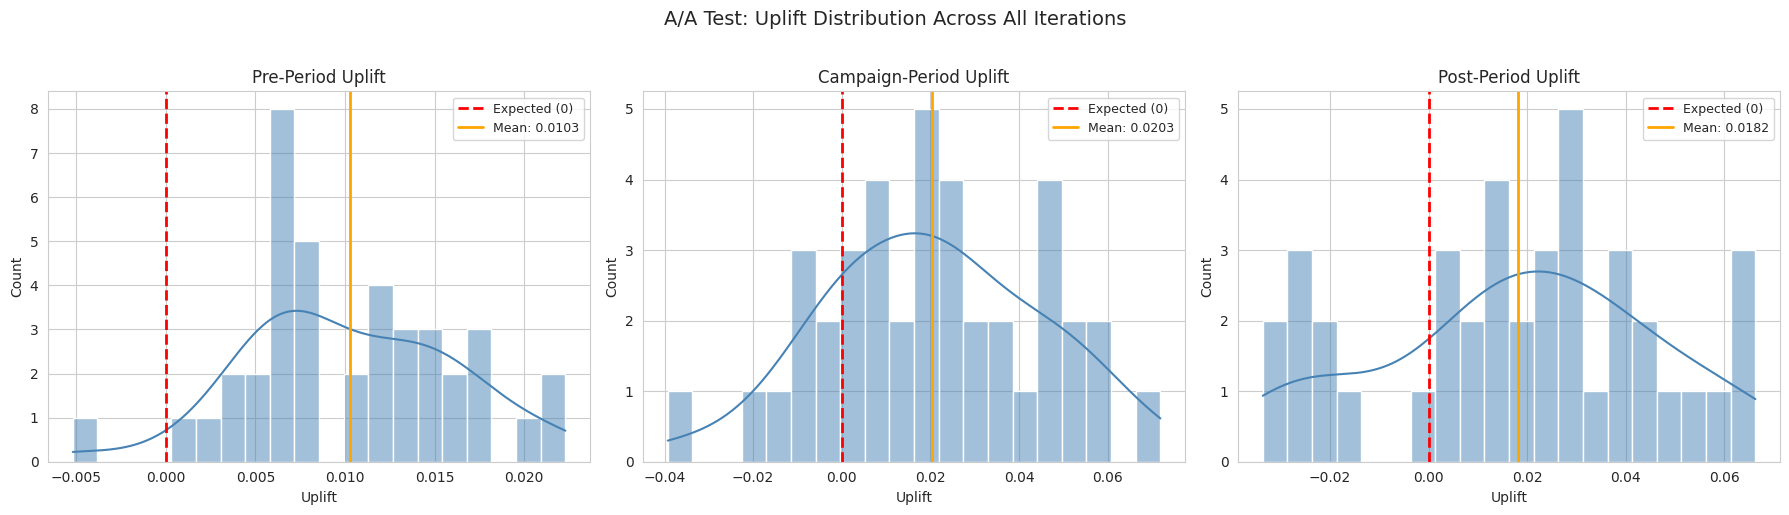

In [11]:
# 10.1 Histogram: uplift distribution across all iterations
periods = ['pre_period_uplift', 'campaign_period_uplift', 'post_period_uplift']
titles = ['Pre-Period Uplift', 'Campaign-Period Uplift', 'Post-Period Uplift']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (period, title) in enumerate(zip(periods, titles)):
    ax = axes[i]
    values = df_metrics[period].dropna()
    sns.histplot(values, kde=True, ax=ax, bins=20, color='steelblue')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Expected (0)')
    ax.axvline(x=values.mean(), color='orange', linestyle='-', linewidth=2,
               label=f'Mean: {values.mean():.4f}')
    ax.set_title(title)
    ax.set_xlabel('Uplift')
    ax.legend(fontsize=9)
plt.suptitle('A/A Test: Uplift Distribution Across All Iterations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

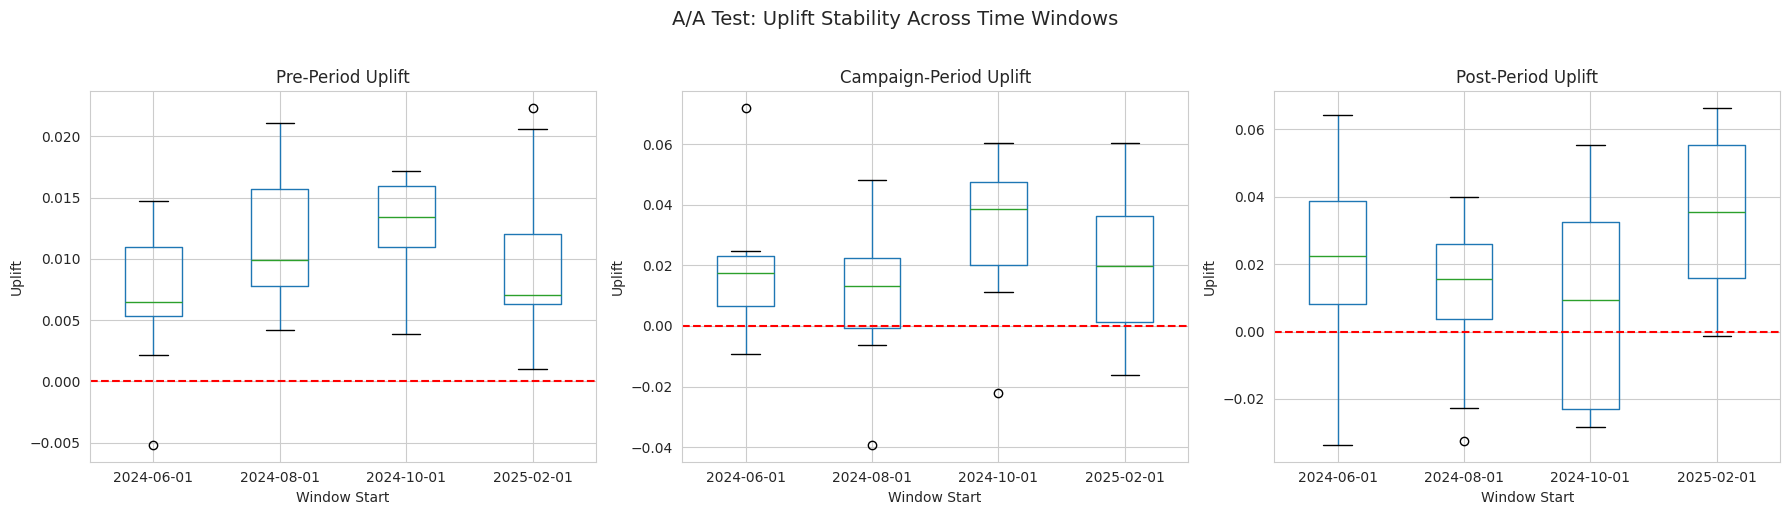

In [12]:
# 10.2 Box plot: uplift by time window (stability)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (period, title) in enumerate(zip(periods, titles)):
    ax = axes[i]
    df_metrics.boxplot(column=period, by='window_start', ax=ax)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(title)
    ax.set_ylabel('Uplift')
    ax.set_xlabel('Window Start')
plt.suptitle('A/A Test: Uplift Stability Across Time Windows', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

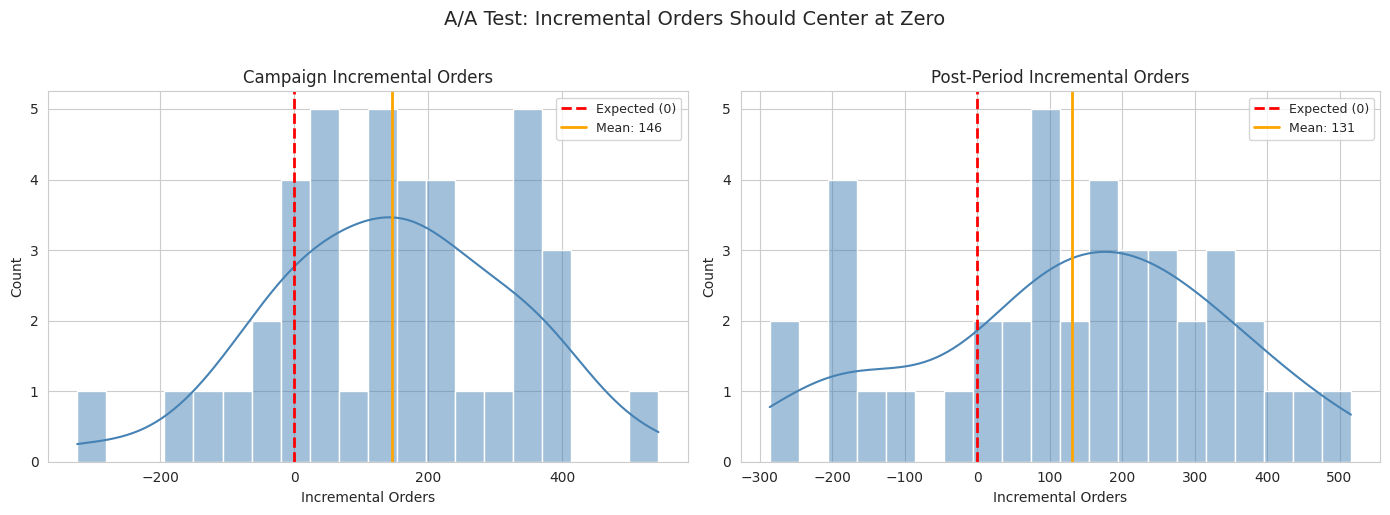

In [13]:
# 10.3 Incremental orders distribution (should center at 0)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (col, title) in enumerate([
    ('campaign_incr_orders', 'Campaign Incremental Orders'),
    ('post_incr_orders', 'Post-Period Incremental Orders'),
]):
    ax = axes[i]
    values = df_metrics[col].dropna()
    sns.histplot(values, kde=True, ax=ax, bins=20, color='steelblue')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Expected (0)')
    ax.axvline(x=values.mean(), color='orange', linestyle='-', linewidth=2,
               label=f'Mean: {values.mean():.0f}')
    ax.set_title(title)
    ax.set_xlabel('Incremental Orders')
    ax.legend(fontsize=9)
plt.suptitle('A/A Test: Incremental Orders Should Center at Zero', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

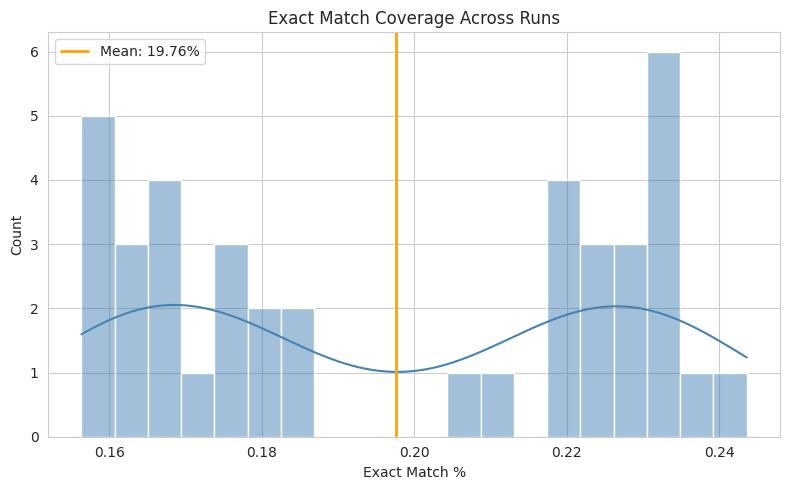

In [14]:
# 10.4 Exact match coverage distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_metrics['exact_match_pct'].dropna(), kde=True, ax=ax, bins=20, color='steelblue')
ax.set_title('Exact Match Coverage Across Runs')
ax.set_xlabel('Exact Match %')
ax.set_ylabel('Count')
mean_cov = df_metrics['exact_match_pct'].mean()
ax.axvline(x=mean_cov, color='orange', linestyle='-', linewidth=2,
           label=f'Mean: {mean_cov:.2%}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 11. Stability Analysis

In [15]:
def stability_analysis(metrics_df):
    """Assess whether bias is consistent across windows or varies."""
    # Cross-window statistics
    window_stats = metrics_df.groupby('window_start').agg({
        'campaign_period_uplift': ['mean', 'std', 'count'],
        'post_period_uplift': ['mean', 'std'],
        'exact_match_pct': ['mean'],
    })
    print('Cross-window statistics:')
    display(window_stats)

    # Levene test for equal variance across windows
    groups = [
        g['campaign_period_uplift'].dropna().values
        for _, g in metrics_df.groupby('window_start')
    ]
    groups = [g for g in groups if len(g) >= 2]

    if len(groups) >= 2:
        levene_stat, levene_p = stats.levene(*groups)
        print(f'\nLevene test for equal variance across windows:')
        print(f'  Statistic: {levene_stat:.4f}, p-value: {levene_p:.4f}')
        if levene_p < 0.05:
            print('  WARNING: Variance differs significantly across windows — '
                  'methodology stability is questionable.')
        else:
            print('  PASS: No significant variance difference across windows.')

        # Kruskal-Wallis test for equal medians
        kruskal_stat, kruskal_p = stats.kruskal(*groups)
        print(f'\nKruskal-Wallis test for equal medians:')
        print(f'  Statistic: {kruskal_stat:.4f}, p-value: {kruskal_p:.4f}')
        if kruskal_p < 0.05:
            print('  WARNING: Median uplift differs across windows — '
                  'bias may be time-dependent.')
        else:
            print('  PASS: No significant difference in median uplift across windows.')
    else:
        print('Not enough window groups for variance tests.')

    return window_stats


window_stats = stability_analysis(df_metrics)

Cross-window statistics:


campaign_period_uplift                 post_period_uplift  \
                               mean       std count               mean   
window_start                                                             
2024-06-01                 0.018138  0.022031    10           0.019187   
2024-08-01                 0.011112  0.024921    10           0.010174   
2024-10-01                 0.031499  0.024694    10           0.007930   
2025-02-01                 0.020570  0.025894    10           0.035470   

                       exact_match_pct  
                   std            mean  
window_start                            
2024-06-01    0.028512        0.229878  
2024-08-01    0.022928        0.222462  
2024-10-01    0.030708        0.162528  
2025-02-01    0.023848        0.175382


Levene test for equal variance across windows:
  Statistic: 0.4978, p-value: 0.6862
  PASS: No significant variance difference across windows.

Kruskal-Wallis test for equal medians:
  Statistic: 3.7024, p-value: 0.2954
  PASS: No significant difference in median uplift across windows.


---
## 12. Summary Report

In [16]:
print('=' * 60)
print('A/A TEST SUMMARY REPORT')
print('=' * 60)

print(f'\nConfiguration:')
print(f'  Markets:           {COUNTRIES}')
print(f'  Time windows:      {len(TIME_WINDOWS)}')
print(f'  Seeds per window:  {N_SEEDS}')
print(f'  Total runs:        {len(df_metrics)}')
print(f'  Script variant:    V3 (with promo correction)')

print(f'\nThresholds:')
print(f'  Hard fail:  |uplift| > {BIAS_THRESHOLD_HARD:.0%}')
print(f'  Warning:    |uplift| > {BIAS_THRESHOLD_WARN:.0%}')

print(f'\nResults:')
for period in ['pre_period_uplift', 'campaign_period_uplift', 'post_period_uplift']:
    vals = df_metrics[period].dropna()
    print(f'  {period}:')
    print(f'    Mean: {vals.mean():.4f}  |  Std: {vals.std():.4f}  |  '
          f'Median: {vals.median():.4f}')

print(f'\n  Exact match coverage: {df_metrics["exact_match_pct"].mean():.2%} '
      f'(std: {df_metrics["exact_match_pct"].std():.2%})')
print(f'  Mean campaign incr. orders: {df_metrics["campaign_incr_orders"].mean():.0f}')
print(f'  Mean post incr. orders: {df_metrics["post_incr_orders"].mean():.0f}')

print(f'\nValidation Scorecard:')
print(df_verdicts.to_string())

print(f'\n{"=" * 60}')
print(f'  OVERALL VERDICT: {overall_verdict}')
print(f'{"=" * 60}')

if overall_verdict == 'PASS':
    print('\nThe Customer Lookalike V3 methodology shows no statistically')
    print('significant bias during non-campaign periods. Proceed with confidence.')
elif overall_verdict == 'WARNING':
    print('\nThe methodology shows borderline bias. Investigate:')
    print('  - Are the dummy windows truly campaign-free?')
    print('  - Is the exact match coverage sufficient?')
    print('  - Consider running with more seeds or different windows.')
else:
    print('\nThe methodology shows significant inherent bias. Do NOT trust')
    print('results from this technique without further optimization.')
    print('  - Investigate matching conditions and feature selection.')
    print('  - Consider geographical constraints (Phase 2).')

A/A TEST SUMMARY REPORT

Configuration:
  Markets:           ['DE']
  Time windows:      4
  Seeds per window:  10
  Total runs:        40
  Script variant:    V3 (with promo correction)

Thresholds:
  Hard fail:  |uplift| > 5%

Results:
  pre_period_uplift:
    Mean: 0.0103  |  Std: 0.0059  |  Median: 0.0094
  campaign_period_uplift:
    Mean: 0.0203  |  Std: 0.0246  |  Median: 0.0205
  post_period_uplift:
    Mean: 0.0182  |  Std: 0.0279  |  Median: 0.0202

  Exact match coverage: 19.76% (std: 3.03%)
  Mean campaign incr. orders: 146
  Mean post incr. orders: 131

Validation Scorecard:
                       abs_mean_uplift p_value             ci_95 ci_contains_zero  verdict
pre_period_uplift               0.0103  0.0000  [0.0085, 0.0121]            False  WARNING
campaign_period_uplift          0.0203  0.0000  [0.0129, 0.0279]            False  WARNING
post_period_uplift              0.0182  0.0002  [0.0096, 0.0266]            False  WARNING

  OVERALL VERDICT: WARNING

The methodol

---
## 13. Persist Results to BigQuery (Optional)

In [17]:
PERSIST_RESULTS = False  # Set to True to save results to BigQuery

AA_RESULTS_TABLE = 'just-data-warehouse.customer_intelligence.customer_lookalike_aa_results'

if PERSIST_RESULTS:
    schema = [
        bigquery.SchemaField('window_start', 'STRING'),
        bigquery.SchemaField('seed', 'INTEGER'),
        bigquery.SchemaField('country', 'STRING'),
        bigquery.SchemaField('n_customers', 'INTEGER'),
        bigquery.SchemaField('exact_match_pct', 'FLOAT'),
        bigquery.SchemaField('pre_period_uplift', 'FLOAT'),
        bigquery.SchemaField('campaign_period_uplift', 'FLOAT'),
        bigquery.SchemaField('post_period_uplift', 'FLOAT'),
        bigquery.SchemaField('campaign_incr_orders', 'FLOAT'),
        bigquery.SchemaField('post_incr_orders', 'FLOAT'),
        bigquery.SchemaField('incr_correction_factor', 'FLOAT'),
    ]

    persist_cols = [s.name for s in schema]
    df_persist = df_metrics[persist_cols].copy()

    job_config = bigquery.LoadJobConfig(
        schema=schema,
        write_disposition='WRITE_APPEND',
    )
    job = client.load_table_from_dataframe(df_persist, AA_RESULTS_TABLE, job_config=job_config)
    job.result()
    print(f'Persisted {len(df_persist)} rows to {AA_RESULTS_TABLE}')
else:
    print('Results not persisted. Set PERSIST_RESULTS = True to save to BigQuery.')

Results not persisted. Set PERSIST_RESULTS = True to save to BigQuery.
